# HumanLens AI — Text Exploratory Data Analysis

## Objective

This notebook performs exploratory analysis of the text data used for
the HumanLens AI text intelligence layer.

The analysis focuses on understanding:

- Text length and structure
- Word and character distributions
- Toxic and non-toxic text characteristics
- Special characters and noisy text
- Extremely short and long comments
- Potential preprocessing requirements
- Characteristics that may affect toxicity and aggression detection

## Multilingual Research Direction

HumanLens is designed as a multilingual system with particular
importance given to:

- English
- Hindi
- Hinglish / Hindi-English code-mixed text
- Indian languages
- Additional languages where reliable training and evaluation data
  are available

The current Civil Comments dataset provides the English foundation
for this stage of the research.

Multilingual datasets will be incorporated in later stages and
evaluated separately by language.

## Important Research Principle

Exploratory analysis is performed before preprocessing and model
training so that preprocessing decisions are based on observed
characteristics of the data rather than assumptions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data_path = Path("../data/processed/civil_comments_train_dev_100k.csv")

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (100000, 9)


In [3]:
print("Text column type:", df["text"].dtype)
print("Number of text entries:", len(df))

print("\nFirst 5 comments:")
display(df["text"].head())

Text column type: object
Number of text entries: 100000

First 5 comments:


0    Socialists? What the hell does that have to do...
1    And I always thought that Eric Trump was the d...
2    I’m disappointed there’s no report from CB on ...
3    Nothing like subsidizing a country that is thr...
4    The only way to save the rhino is to legalize ...
Name: text, dtype: object

In [4]:
df["character_count"] = df["text"].fillna("").str.len()

df["word_count"] = (
    df["text"]
    .fillna("")
    .str.split()
    .str.len()
)

df["sentence_count"] = (
    df["text"]
    .fillna("")
    .str.count(r"[.!?]+")
)

print("Text features created successfully.")

Text features created successfully.


In [5]:
text_stats = df[
    ["character_count", "word_count", "sentence_count"]
].describe().T

text_stats

,count,mean,std,min,25%,50%,75%,max
character_count,100000.0,295.69817,267.782019,1.0,94.0,201.0,411.0,1535.0
word_count,100000.0,51.03452,45.970233,1.0,16.0,35.0,71.0,266.0
sentence_count,100000.0,3.79881,3.188582,0.0,2.0,3.0,5.0,48.0


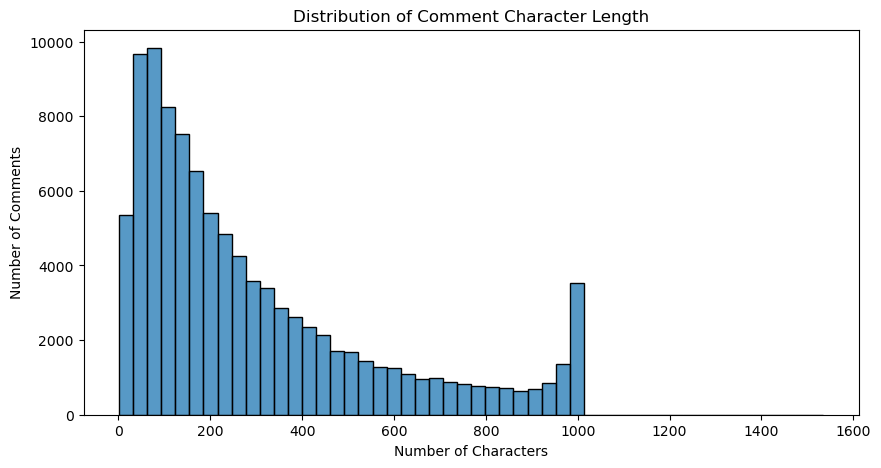

In [6]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["character_count"],
    bins=50
)

plt.title("Distribution of Comment Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Comments")

plt.show()

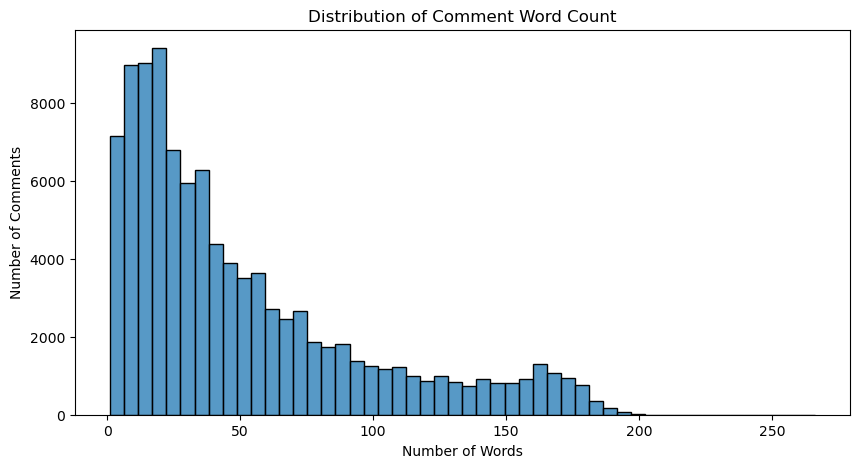

In [7]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["word_count"],
    bins=50
)

plt.title("Distribution of Comment Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Number of Comments")

plt.show()

In [8]:
grouped_text_stats = (
    df.groupby("is_toxic")[["character_count", "word_count"]]
    .mean()
)

grouped_text_stats

,character_count,word_count
is_toxic,,
0,297.258431,51.262337
1,277.346988,48.355028


In [9]:
print("0 = Non-toxic")
print("1 = Toxic")

grouped_text_stats

0 = Non-toxic
1 = Toxic


,character_count,word_count
is_toxic,,
0,297.258431,51.262337
1,277.346988,48.355028


In [10]:
short_comments = df[
    df["word_count"] <= 2
][["text", "toxicity", "is_toxic", "word_count"]]

print("Comments with 2 or fewer words:", len(short_comments))

short_comments.head(20)

Comments with 2 or fewer words: 1676


,text,toxicity,is_toxic,word_count
9,Love it!,0.0,0,2
59,Are you?,0.0,0,2
151,https://www.change.org/p/prime-minister-justin...,0.0,0,1
271,*sarcasm*,0.0,0,1
287,Amen.,0.0,0,1
291,Figures,0.1,0,1
360,... COWARD!,0.6,1,2
369,hello,0.0,0,1
430,Excellent news!!,0.0,0,2
440,Relevance?,0.0,0,1


In [11]:
long_comments = df[
    df["word_count"] >= df["word_count"].quantile(0.99)
][["text", "toxicity", "is_toxic", "word_count"]]

print("Number of extremely long comments:", len(long_comments))

long_comments.head(10)

Number of extremely long comments: 1111


,text,toxicity,is_toxic,word_count
23,The issue of paying RRSP/TFSA fees outside the...,0.000000,0,185
178,"Mr. Abbott,\n\nI'm re-reading your post, tryin...",0.200000,0,178
281,Reality check :The reason conservatives don't ...,0.000000,0,187
295,Censorship is alive and well in the USA. Some ...,0.166667,0,183
588,Being able to pass STEM training shows that yo...,0.000000,0,180
648,I am truly saddened to see our country once ag...,0.000000,0,184
1091,Alaskans are happy to see oil prices go up so ...,0.000000,0,178
1535,What a speech ! Trump hit a grand slam home r...,0.500000,1,181
1603,"You continued with your argument, not even beg...",0.000000,0,178
1841,"Hilarious, but I'll only bother with one. let'...",0.000000,0,183


In [12]:
df["has_url"] = df["text"].fillna("").str.contains(
    r"https?://|www\.",
    regex=True
)

df["has_mention"] = df["text"].fillna("").str.contains(
    r"@\w+",
    regex=True
)

df["has_excessive_punctuation"] = df["text"].fillna("").str.contains(
    r"[!?]{2,}",
    regex=True
)

print("URLs:", df["has_url"].sum())
print("Mentions:", df["has_mention"].sum())
print("Excessive punctuation:", df["has_excessive_punctuation"].sum())

URLs: 2900
Mentions: 185
Excessive punctuation: 3284


In [13]:
high_toxicity_examples = (
    df.sort_values("toxicity", ascending=False)
      [["text", "toxicity", "insult", "threat", "obscene"]]
      .head(20)
)

high_toxicity_examples

,text,toxicity,insult,threat,obscene
47199,Trump is a very ill man. During those periods...,1.0,1.000000,0.000000,0.000000
9629,Sic on by the hair brain Celebs - jeez just li...,1.0,1.000000,0.000000,0.166667
98015,Get ready for pathetic keyboard warriors to us...,1.0,1.000000,0.000000,0.000000
10624,Oh silly,1.0,1.000000,0.000000,0.000000
4315,That is one of the most idiotic titles for an ...,1.0,1.000000,0.000000,0.300000
6826,Sounds like he is guilty of being a boor. Agei...,1.0,1.000000,0.000000,0.000000
74157,"Rodrigo, ""you should think before you make sil...",1.0,1.000000,0.000000,0.000000
35999,Microagression and liberal white guilt.,1.0,1.000000,0.000000,0.000000
74257,Calling her crazy is a disservice to all the c...,1.0,0.833333,0.166667,0.000000
58336,The best thing Canada can do for its high tech...,1.0,1.000000,0.000000,0.000000
